In [7]:
# ================================
# 1. 필요한 라이브러리 가져오기
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine             # 와인 데이터셋

import joblib                                      # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                            # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [8]:
# ================================
# 2. CIFART-10 데이터 불러오기
# ================================
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
#CIFAR-10 이미지는 32X32 컬러 이미지이고, 10개 클래스로 구성
# y 데이터(배치,1) 형태이기때문 reshape 필요

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [9]:
# ================================
# 3. 데이터 정규화
# ================================
X_train = X_train / 255.0   # RGB 값을 0~1 범위로 정규화한것.
X_test = X_test / 255.0

In [10]:
# ================================
# 4. 시각화를 위한 클래스 이름 정의
# ================================
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [11]:
# ================================
# 5. 데이터 증강(Data Augmentation) 정의
# ================================
#data_augmentation = tf.keras.Sequential([
#    layers.RandomFlip("horizontal"), #이미지 좌우 랜덤하게 뒤집기
#    layers.RandomRotation(0.05),     # 랜덤하게 회전 적용, 0.1 -> 0.05 줄이기
#    layers.RandomZoom(0.1),          # 랜덤하게 확대/축소
#    layers.RandomContrast(0.1)       # 명암 효과 (밝은 것은 더 밝게, 어두운 것은 어둡게하여 선명도 개선)
#])

In [13]:
# ================================
# 6. CNN + Dropout 모델 구성
# ================================
model = models.Sequential([
    #data_augmentation,

    # 첫 번째 CNN Layer
    layers.Conv2D(32, (3,3), padding='same'), # 컬러 이미지 입력
    layers.BatchNormalization(),              # 특징 추출해서 크기를 감소
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.5),

    # 두 번째 CNN Layer
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.5),

    # 세 번째 CNN Layer
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Fully Connected layer
    layers.Flatten(),                             # 2D --> 10 벡터로 변환
    layers.Dense(256),                            # 256개의 뉴련의 학습
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(10, activation='softmax')         # 10개의 클래스에 대한 확률 출력
])

In [14]:
# ================================
# 7. 모델 컴파일
# ================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# ================================
# 8.모델 학습
# ================================
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.3975 - loss: 1.7030 - val_accuracy: 0.2118 - val_loss: 3.3659
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5086 - loss: 1.3604 - val_accuracy: 0.3256 - val_loss: 2.2367
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 49ms/step - accuracy: 0.5594 - loss: 1.2238 - val_accuracy: 0.2585 - val_loss: 2.6987
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.5996 - loss: 1.1236 - val_accuracy: 0.4085 - val_loss: 1.9095
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6306 - loss: 1.0455 - val_accuracy: 0.3014 - val_loss: 2.7804
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6518 - loss: 0.9897 - val_accuracy: 0.4336 - val_loss: 1.8673
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.6653 - loss: 0.9489 - val_accuracy: 0.3205 - val_loss: 2.8531
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6801 - loss: 0.9097 - 

In [17]:
# ================================
# 9. 테스트 데이터 평가
# ================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"CIFAR-10 테스트 정확도: {test_acc:.4f}")
print(f"CIFAR-10 테스트 손실값: {test_loss:.4f}")

CIFAR-10 테스트 정확도: 0.5941
CIFAR-10 테스트 손실값: 1.3492


C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA

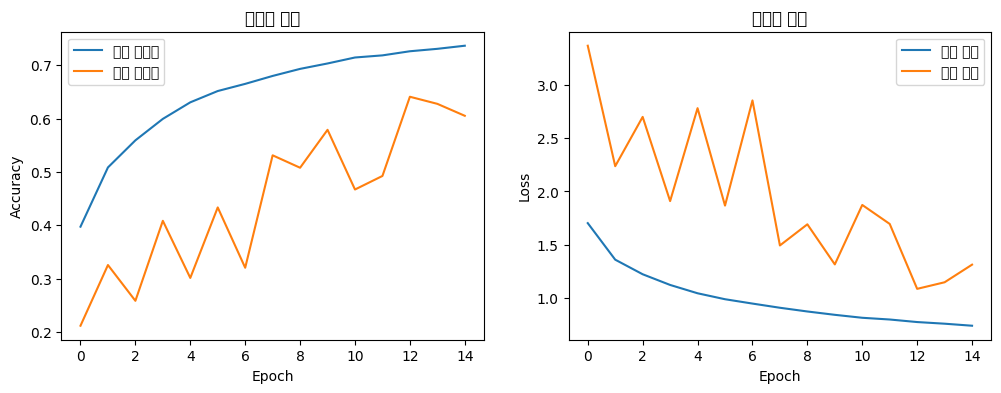

In [18]:
# ================================
# 10. 학습 곡선(정확도/손실) 시각화
# ================================
plt.figure(figsize=(12,4))

# --- 정확도 그래프 ---
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='훈련 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title("정확도 변화")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# --- 손실 그래프 ---
plt.subplot(1,2,2,)
plt.plot(history.history['loss'], label='훈련 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title("손실값 변화")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [21]:
# ================================
# 11. 예측 수행
# ================================
predictions = model.predict(X_test)
pred_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL

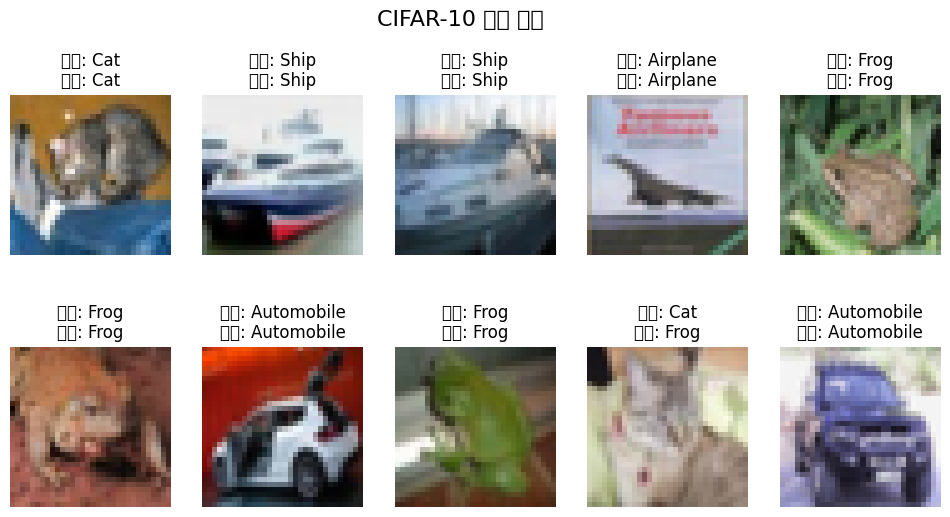

In [22]:
# ================================
# 2. 앞 10개 이미지 예측 시각화
# ================================
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title(f"정답: {class_names[y_test[i]]}\n예측: {class_names[pred_labels[i]]}")
    plt.axis("off")
plt.suptitle("CIFAR-10 예측 결괴", fontsize=16)
plt.show()